# 权重衰减

## 环境配置


In [1]:
import os, sys, warnings, logging
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
logging.getLogger("matplotlib").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="Cannot create tensor with internal format")
import pypto
import torch
from torch import nn
import torch_npu
from d2l import torch as d2l
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import numpy as np

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


## 练习4.5.1

在本节的估计问题中使用$\lambda$的值进行实验。绘制训练和测试精度关于$\lambda$的函数图。可以观察到什么？

**解答：** 随着$\lambda$增加，训练损失和测试损失逐渐靠近，但最终没有靠到一起。

以下使用 `torch` 编程进行验证：


In [ ]:
import numpy as np

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)
net = nn.Sequential(nn.Linear(num_inputs, 1))
loss = nn.MSELoss(reduction='none')

def train_wd(wdlist, net, loss, train_iter, test_iter, layer=[0], num_epochs=100, lr=0.003):
    animator = d2l.Animator(xlabel='λ', ylabel='loss', yscale='log',
                            xlim=[wdlist[0], wdlist[-1]], legend=['train', 'test'])
    for param in net.parameters():
        param.data.normal_()
    # 偏置参数没有衰减
    for wd in wdlist:
        for i in layer:
            trainer = torch.optim.SGD([
                {"params": net[i].weight, 'weight_decay': wd},
                {"params": net[i].bias}], lr=lr)
            for epoch in range(num_epochs):
                for X, y in train_iter:
                    trainer.zero_grad()
                    l = loss(net(X), y)
                    l.mean().backward()
                    trainer.step()
        animator.add(wd, (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))

train_wd(np.linspace(0., 100., 150), net, loss, train_iter, test_iter)


使用 `PyPTO` 编程进行验证:


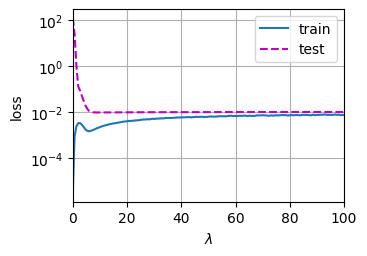

In [2]:
from src.utils import synthetic_data, load_array, Animator, evaluate_loss
from src.pypto_ops import PyPTOLinear, mse_loss

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1), device=device) * 0.01, 0.05
train_data = synthetic_data(true_w, true_b, n_train, device=device)
train_iter = load_array(train_data, batch_size)
test_data = synthetic_data(true_w, true_b, n_test, device=device)
test_iter = load_array(test_data, batch_size, is_train=False)

net = nn.Sequential(PyPTOLinear(num_inputs, 1)).to(device)
loss = lambda y_hat, y: mse_loss(y_hat, y, reduction='none')

def train_wd(wdlist, net, loss, train_iter, test_iter, layer=[0], num_epochs=100, lr=0.003):

    animator = Animator(xlabel='$\\lambda$', ylabel='loss', yscale='log',
                            xlim=[wdlist[0], wdlist[-1]], legend=['train', 'test'])
    for param in net.parameters():
        param.data.normal_()
    # 偏置参数没有衰减
    for wd in wdlist:
        for i in layer:
            trainer = torch.optim.SGD([
                {"params": net[i].weight, 'weight_decay': wd},
                {"params": net[i].bias}], lr=lr)
            for epoch in range(num_epochs):
                for X, y in train_iter:
                    trainer.zero_grad()
                    l = loss(net(X), y)
                    l.mean().backward()
                    trainer.step()

        animator.add(wd, (evaluate_loss(net, train_iter, loss),
                          evaluate_loss(net, test_iter, loss)))

train_wd(np.linspace(0., 100., 150), net, loss, train_iter, test_iter)

## 练习4.5.2

使用验证集来找到最佳值$\lambda$。它真的是最优值吗？这有关系吗？

**解答：** 不一定是最优的解，但绝对不是过拟合的解。

## 练习4.5.3

如果我们使用$\sum_i |w_i|$作为我们选择的惩罚（$L_1$正则化），那么更新方程会是什么样子？

**解答：**

$$L(\mathbf{w}, b)+\lambda\|\mathbf{w}\|_1$$

$$\mathbf{w} \leftarrow \mathbf{w}-\eta \lambda \operatorname{sign}(\mathbf{w})-\frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)}\left(\mathbf{w}^{\top} \mathbf{x}^{(i)}+b-y^{(i)}\right)$$

## 练习4.5.4

我们知道$\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$。能找到类似的矩阵方程吗？

**解答：** $$\|\mathbf{W}\|_F = \left[\sum_{i,j} \mathbf{W}[i,j]^2\right]^{1 / 2}$$

## 练习4.5.5

回顾训练误差和泛化误差之间的关系。除了权重衰减、增加训练数据、使用适当复杂度的模型之外，还能想出其他什么方法来处理过拟合？

**解答：** 可以在验证误差下降到最低点的时候停止训练，防止过拟合。

## 练习4.5.6

在贝叶斯统计中，我们使用先验和似然的乘积，通过公式$P(w \mid x) \propto P(x \mid w) P(w)$得到后验。如何得到带正则化的$P(w)$？

**解答：** 如果考虑最大后验估计（MAP）:

$$w=\underset{w}{\arg \max} P(w \mid x)=\underset{w}{\arg \max}(P(x \mid w) P(w))=\underset{w}{\arg \max}\log(P(x \mid w) P(w))=\underset{w}{\arg \max}(\log P(x \mid w) + \log P(w))$$

如果考虑$P(w)$为正态分布 $w_i \sim N\left(0, \sigma^2\right)$:

$$\log P(w)=\log \prod_i \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{\left(w_i-0\right)^2}{2 \sigma^2}} =-\frac{1}{2 \sigma^2} \sum_i w_i^2+C$$

将得到$L_2$正则化的结果。

如果考虑$P(w)$为拉普拉斯分布 $w_i \sim \operatorname{Laplace}(0, b)$:

$$\log P(w) =\log \prod_i \frac{1}{2 b} e^{-\frac{\left|w_i-0\right|}{b}} =-\frac{1}{b} \sum_i\left|w_i\right|+C$$

将得到$L_1$正则化的结果。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
